In [1]:
import numpy as np
import torch

from torchgpe.bec2D import Gas
from torchgpe.bec2D.potentials import LinearPotential, Union, Callable, any_time_dependent_variable, time_dependent_variable
from torchgpe.utils.potentials import NonLinearPotential

import sys
import importlib
sys.path.append('..')

import two_component_variable_gas
importlib.reload(two_component_variable_gas)
from two_component_variable_gas import TwoComponentGas


In [89]:
from peden_two_state_3D import set_two_component_molecular_mass, Trap3D, PedenDirectDDI3D, initialize_two_component_gaussian

mass_amu = 220.0

N_up = int(500)
N_down = int(500)

gas = TwoComponentGas(
    element="87Rb",
    N_particles=(N_up, N_down),
    N_grid=64,
    grid_size=(3400e-9, 3400e-9, 1000e-9),
    adimensionalization_length=1e-6,
    device="cuda"
)

set_two_component_molecular_mass(gas, mass_amu=mass_amu)

3.65318594652e-25

In [18]:
from peden_two_state_3D import ComponentDiagnostics

# Quasi-2D / pancake trap.
# Frequencies must be angular frequencies, rad/s.
omega_x = 2 * np.pi * 400
omega_y = 2 * np.pi * 400
omega_z = 2 * np.pi * 4000

trap = Trap3D(
    omegax=omega_x,
    omegay=omega_y,
    omegaz=omega_z,
)

# -------------------------
# Two dipole states
# -------------------------
# Simplified dipole-basis model:
#   |up>   has d = +d0
#   |down> has d = -d0
#
# Replace d0_debye with the dipole moment appropriate for your molecule/state.
# If the run becomes unstable, reduce d0_debye, N, or the time step.
d0_debye = 1.0

ddi = PedenDirectDDI3D(
    d_up_debye=+d0_debye,
    d_down_debye=-d0_debye,
    polarization=(0.0, 0.0, 1.0),
)

# Initialize.
initialize_two_component_gaussian(
    gas,
    omega_x=omega_x,
    omega_y=omega_y,
    omega_z=omega_z,
)

# Initialize once to print couplings before the run.
ddi.set_gas(gas)
ddi.on_propagation_begin()
ddi.print_couplings()

diagnostics = ComponentDiagnostics(
    compute_every=100,
    print_every=5000,
)

Initial Gaussian widths
-----------------------
sigma_x = 0.3389 um
sigma_y = 0.3389 um
sigma_z = 0.1072 um
Dimensionless DDI couplings
---------------------------
g_up_up        = 6.879832e+05
g_down_down    = 6.879832e+05
g_up_from_down = -6.879832e+05
g_down_from_up = -6.879832e+05


In [31]:
# -------------------------
# Ground state
# -------------------------
# With strong electric dipoles, start cautiously.
# If stable, you can increase |time_step| gradually.
gas.ground_state(
    potentials=[trap, ddi],
    time_step=-1e-6j,
    N_iterations=20_000,
    callbacks=[diagnostics],
    leave_progress_bar=True,
)

Ground state:   0%|          | 0/20000 [00:00<?]

epoch        0 | norm_up=0.500000, norm_down=0.500000 | rms_up=(0.027, 0.027, 0.024) um | rms_down=(0.027, 0.027, 0.024) um
epoch     5000 | norm_up=0.500000, norm_down=0.500000 | rms_up=(0.066, 0.066, 0.021) um | rms_down=(0.066, 0.066, 0.021) um
epoch    10000 | norm_up=0.500000, norm_down=0.500000 | rms_up=(0.066, 0.066, 0.021) um | rms_down=(0.066, 0.066, 0.021) um
epoch    15000 | norm_up=0.500000, norm_down=0.500000 | rms_up=(0.066, 0.066, 0.021) um | rms_down=(0.066, 0.066, 0.021) um


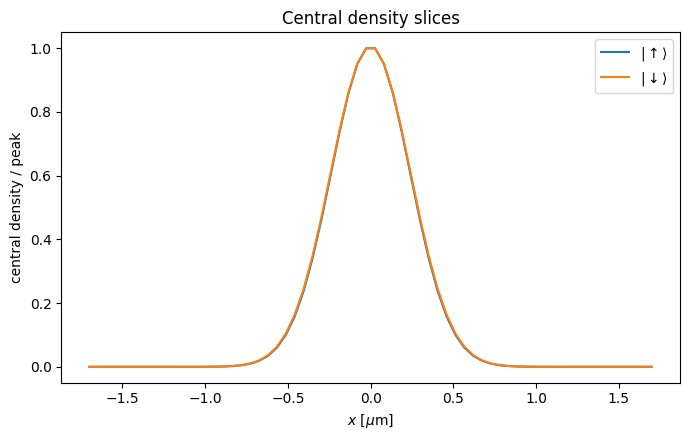

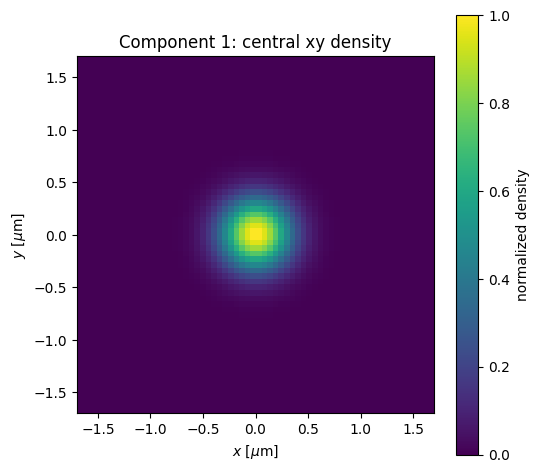

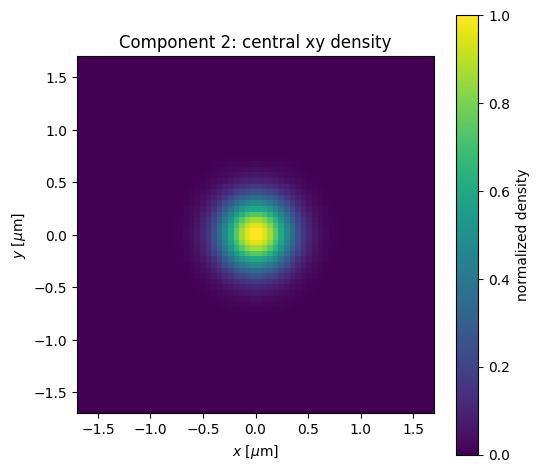

In [96]:
from peden_two_state_3D import plot_central_x_slices, plot_xy_density

plot_central_x_slices(gas, normalize=True)
plot_xy_density(gas, component=0, normalize=True)
plot_xy_density(gas, component=1, normalize=True)

In [90]:
import torch
import numpy as np

import single_molecule_hamiltonian
importlib.reload(single_molecule_hamiltonian)
from single_molecule_hamiltonian import SingleMoleculeHamiltonian
from peden_two_state_3D import PopulationMonitor

delta_Hz = 25.0
Omega_Hz = 50.0

single_molecule = SingleMoleculeHamiltonian(
    delta=2 * np.pi * delta_Hz,
    Omega=2 * np.pi * Omega_Hz,
    phase=0.0,
)

d0_debye = 0.01
ddi = PedenDirectDDI3D(
    d_up_debye=+d0_debye,
    d_down_debye=-d0_debye,
    polarization=(0.0, 0.0, 1.0),
)

import peden_two_state_3D
importlib.reload(peden_two_state_3D)
from peden_two_state_3D import print_imaginary_time_stiffness

single_molecule.set_gas(gas)
single_molecule.on_propagation_begin()

print_imaginary_time_stiffness(
    gas=gas,
    trap=trap,
    ddi=ddi,
    single_molecule=single_molecule,
    time_step=-1e-9j,
)

Single-molecule Hamiltonian diagnostics
--------------------------------------
H_dim eigenvalues: [-0.6083738  0.6083738]
H_dim eigenvalue spread: 1.2167475947548707
Single-molecule Hamiltonian diagnostics
--------------------------------------
H_dim eigenvalues: [-0.6083738  0.6083738]
H_dim eigenvalue spread: 1.2167475947548707
Imaginary-time stiffness diagnostics
-----------------------------------
physical time_step        = (-0-1e-09j)
dimensionless tau         = 2.886718e-07
V_min                     = 2.939196e-01
V_max                     = 1.166567e+03
V_span                    = 1.166273e+03
tau * V_span              = 3.366701e-04
H eigenvalue spread       = 1.216748e+00
tau * H eigenvalue spread = 3.512407e-07


In [91]:
import peden_two_state_3D
importlib.reload(peden_two_state_3D)
from peden_two_state_3D import print_beta_and_D_from_gas_stark_shift

initialize_two_component_gaussian(
    gas,
    omega_x=omega_x,
    omega_y=omega_y,
    omega_z=omega_z,
)

params = print_beta_and_D_from_gas_stark_shift(
    gas,
    d_debye=d0_debye,
    stark_shift_Hz=2*delta_Hz,       # dE/h = 500 Hz
    Delta_Hz=2*Omega_Hz,            # Delta/h = 1000 Hz
    omega_z_rad_s=2*np.pi*4000,
)

Initial Gaussian widths
-----------------------
sigma_x = 0.3389 um
sigma_y = 0.3389 um
sigma_z = 0.1072 um
Dimensionless parameters
------------------------
N_total          = 1.000000e+03
d                = 0.01 Debye
stark shift dE/h = 5.000000e+01 Hz
Delta/h          = 1.000000e+02 Hz
omega_z          = 2.513274e+04 rad/s
mass             = 3.653186e-25 kg
l_z              = 1.071722e-07 m
n2D              = 8.650519e+13 m^-2

beta = dE / Delta                 = 5.000000e-01
D    = n2D d^2/(3 eps0 Delta lz)  = 5.102608e-01


In [95]:
import energy_callback
importlib.reload(energy_callback)
from energy_callback import EffectiveDetuningMonitor

population_cb = PopulationMonitor(
    compute_every=10,
    print_every=10,
)

detuning_cb = EffectiveDetuningMonitor(
    linear_potentials=[trap],
    nonlinear_potentials=[ddi],
    single_molecule=single_molecule,
    compute_every=10,
    print_every=10,
)

gas.ground_state(
    potentials=[trap, ddi, single_molecule],
    time_step=-1e-6j,
    N_iterations=10_000,
    callbacks=[detuning_cb],
)

Single-molecule Hamiltonian diagnostics
--------------------------------------
H_dim eigenvalues: [-0.6083738  0.6083738]
H_dim eigenvalue spread: 1.2167475947548707


Ground state:   0%|          | 0/10000 [00:00<?]

epoch        0 | f1=0.499155, f2=0.500845, f_sum=1.000000 | Delta_center=4.842e-01 | Delta_weighted=5.223e-01 | max|Delta|/Omega=5.273e-01 | max density=1.433e+01
epoch       10 | f1=0.498419, f2=0.501581, f_sum=1.000000 | Delta_center=4.346e-01 | Delta_weighted=5.035e-01 | max|Delta|/Omega=5.505e-01 | max density=1.433e+01
epoch       20 | f1=0.497711, f2=0.502289, f_sum=1.000000 | Delta_center=3.881e-01 | Delta_weighted=4.857e-01 | max|Delta|/Omega=5.724e-01 | max density=1.433e+01
epoch       30 | f1=0.497030, f2=0.502970, f_sum=1.000000 | Delta_center=3.443e-01 | Delta_weighted=4.688e-01 | max|Delta|/Omega=5.930e-01 | max density=1.433e+01
epoch       40 | f1=0.496376, f2=0.503624, f_sum=1.000000 | Delta_center=3.027e-01 | Delta_weighted=4.525e-01 | max|Delta|/Omega=6.126e-01 | max density=1.433e+01
epoch       50 | f1=0.495746, f2=0.504254, f_sum=1.000000 | Delta_center=2.631e-01 | Delta_weighted=4.370e-01 | max|Delta|/Omega=6.311e-01 | max density=1.433e+01
epoch       60 | f1=0.

In [13]:
def expected_lower_state_fractions(delta, Omega):
    R = np.sqrt(delta**2 + Omega**2)
    f1 = 0.5 * (1 - delta / R)
    f2 = 0.5 * (1 + delta / R)
    return f1, f2

print(expected_lower_state_fractions(delta_Hz, Omega_Hz))

(np.float64(0.401941932430908), np.float64(0.5980580675690921))
